## sediment


In [1]:

import geopandas as gpd
import pandas as pd


#Read in shapefile tags
ahp = gpd.read_file("/fs9/eliviau/hex2vec_project/land_use_framework/data/sediment_tags") #specify which tags to use


/home/eliviau/miniconda3/envs/hex2vec_env/lib/python3.9/site-packages/pyogrio/raw.py:198: RuntimeWarning: /fs9/eliviau/hex2vec_project/land_use_framework/data/sediment_tags/sediment_tags.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


In [2]:
ahp.head()

,feature_id,sediment_r,geometry
0,0,1,"MULTIPOLYGON (((134.54178 34.07073, 134.54168 ..."
1,1,1,"MULTIPOLYGON (((134.54301 34.07243, 134.54296 ..."
2,2,1,"MULTIPOLYGON (((134.5729 34.01901, 134.57264 3..."
3,3,1,"MULTIPOLYGON (((134.53485 33.94418, 134.5345 3..."
4,4,1,"MULTIPOLYGON (((134.48606 34.01857, 134.48606 ..."


In [3]:
ahp["sediment_r"].unique()

array([1, 3, 2])

In [4]:
ahp.head()

,feature_id,sediment_r,geometry
0,0,1,"MULTIPOLYGON (((134.54178 34.07073, 134.54168 ..."
1,1,1,"MULTIPOLYGON (((134.54301 34.07243, 134.54296 ..."
2,2,1,"MULTIPOLYGON (((134.5729 34.01901, 134.57264 3..."
3,3,1,"MULTIPOLYGON (((134.53485 33.94418, 134.5345 3..."
4,4,1,"MULTIPOLYGON (((134.48606 34.01857, 134.48606 ..."


In [5]:
from srai.regionalizers import geocode_to_region_gdf

# Step 1: Get the boundary for Yamagata prefecture
area = geocode_to_region_gdf("Hokkaido, Japan")
area.crs  # should return EPSG:4326

/home/eliviau/miniconda3/envs/hex2vec_env/lib/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [6]:
area.head()

,geometry
region_id,
"Hokkaido Prefecture, Japan","POLYGON ((139.06728 41.51453, 139.06751 41.506..."


In [7]:
from srai.regionalizers import H3Regionalizer

# Step 2: Create H3 hexagons for Yamagata
regionalizer = H3Regionalizer(resolution=7)  # resolution 9 = ~500m hexes
regions = regionalizer.transform(area)

regions.head()

,geometry
region_id,
872ea89b6ffffff,"POLYGON ((144.83066 44.23914, 144.82691 44.251..."
872ef0d1bffffff,"POLYGON ((141.17013 44.63593, 141.16582 44.648..."
872e19416ffffff,"POLYGON ((141.1905 42.24812, 141.18635 42.2603..."
872e132dcffffff,"POLYGON ((144.1739 42.91204, 144.17013 42.9245..."
872ef4065ffffff,"POLYGON ((141.3764 43.83708, 141.37218 43.8492..."


In [8]:
regions.shape

(28902, 1)

step 3 : join 

In [9]:
from srai.joiners import IntersectionJoiner

# Make sure CRS matches!
ahp = ahp.to_crs(regions.crs)

# Step 3: Use IntersectionJoiner to match land cover to hexagons
joiner = IntersectionJoiner()
joined = joiner.transform(regions, ahp)

# Preview the result
joined.head()


,
region_id,feature_id
872e1e48effffff,1259533
872e1e483ffffff,1259533
872e13774ffffff,1259534
872e13729ffffff,1259534
872ead975ffffff,1259535


In [10]:
joined.shape

(22794, 0)

In [10]:
# Bring region_id back as a column
joined = joined.reset_index()

# Now merge safely
joined_with_tags = joined.merge(
    ahp[["feature_id", "sediment_r"]],
    on="feature_id",
    how="left"
)

In [11]:
joined_with_tags.head()

,region_id,feature_id,sediment_r
0,872e1e48effffff,1259533,3
1,872e1e483ffffff,1259533,3
2,872e13774ffffff,1259534,3
3,872e13729ffffff,1259534,3
4,872ead975ffffff,1259535,3


In [12]:
ahp_score = {
   3: 0,
   2: 0,
   3 :0
}

In [13]:
joined_with_tags["ahp_score"] = joined_with_tags["sediment_r"].map(ahp_score)


In [14]:
ahp.head()

,feature_id,sediment_r,geometry
0,0,1,"MULTIPOLYGON (((134.54178 34.07073, 134.54168 ..."
1,1,1,"MULTIPOLYGON (((134.54301 34.07243, 134.54296 ..."
2,2,1,"MULTIPOLYGON (((134.5729 34.01901, 134.57264 3..."
3,3,1,"MULTIPOLYGON (((134.53485 33.94418, 134.5345 3..."
4,4,1,"MULTIPOLYGON (((134.48606 34.01857, 134.48606 ..."


In [15]:
joined_with_tags["ahp_score"] = joined_with_tags["sediment_r"].map(ahp_score)


In [16]:
hex_scores = joined_with_tags.groupby("region_id")["ahp_score"].mean().reset_index()
hex_scores.columns = ["region_id", "ahp_score"]


In [17]:
# Merge scores into hexagon GeoDataFrame
regions_scored = regions.merge(hex_scores, on="region_id", how="left")


In [18]:
regions_scored.head(30)

,region_id,geometry,ahp_score
0,872ea89b6ffffff,"POLYGON ((144.83066 44.23914, 144.82691 44.251...",NaN
1,872ef0d1bffffff,"POLYGON ((141.17013 44.63593, 141.16582 44.648...",NaN
2,872e19416ffffff,"POLYGON ((141.1905 42.24812, 141.18635 42.2603...",NaN
3,872e132dcffffff,"POLYGON ((144.1739 42.91204, 144.17013 42.9245...",NaN
4,872ef4065ffffff,"POLYGON ((141.3764 43.83708, 141.37218 43.8492...",NaN
5,872ef66e1ffffff,"POLYGON ((141.54363 45.41341, 141.53933 45.425...",NaN
6,872e1b172ffffff,"POLYGON ((141.21558 42.76974, 141.2114 42.7819...",NaN
7,872e1bba9ffffff,"POLYGON ((141.01733 42.54391, 141.01314 42.556...",NaN
8,872ef6d31ffffff,"POLYGON ((142.64272 44.88008, 142.63861 44.892...",NaN
9,872e1b214ffffff,"POLYGON ((140.73145 42.95009, 140.72719 42.962...",0.0


In [19]:
regions_scored["ahp_score"] = regions_scored["ahp_score"].fillna(10)

In [21]:
#regions_scored save to output
regions_scored.to_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/hokkaido_ahp_sedimentreso7.geojson", driver="GeoJSON")

In [21]:
from srai.plotting import plot_numeric_data

#remettre le index 
regions_scored = regions_scored.set_index("region_id")

m = plot_numeric_data(regions_scored, "ahp_score", colormap="YlGnBu", opacity=0.6)
m.save("sediment_yamagata_map.html")


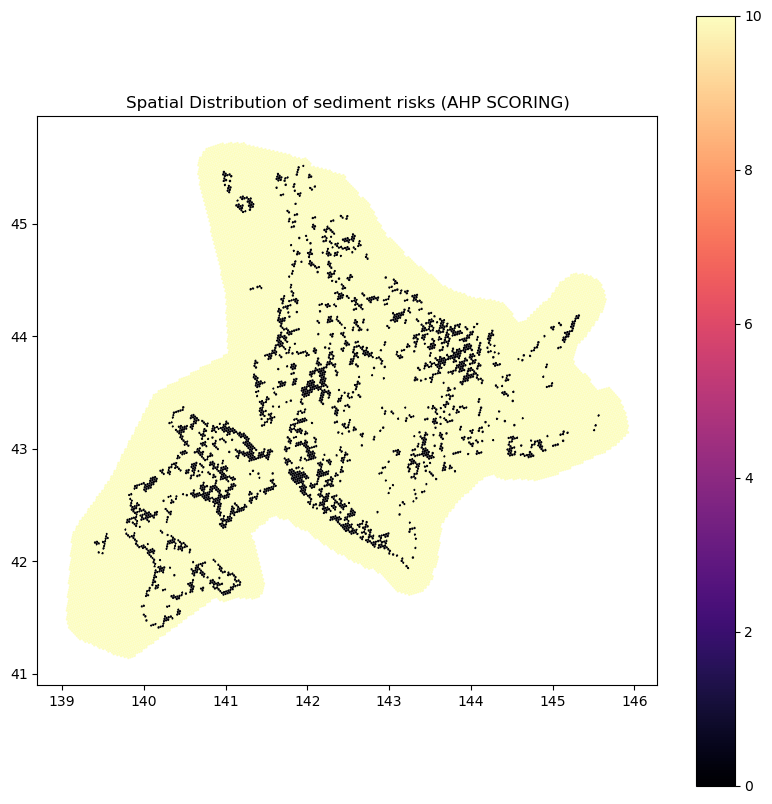

In [31]:
#other map 

#other quickmap 
# If you still have 'regions' geodataframe loaded:


from matplotlib import pyplot as plt


regions_scored.plot(
    column='ahp_score',
    cmap='magma',
    legend=True,
    figsize=(10,10)
)
plt.title("Spatial Distribution of sediment risks (AHP SCORING)")
plt.show()


/tmp/ipykernel_55003/4292001234.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


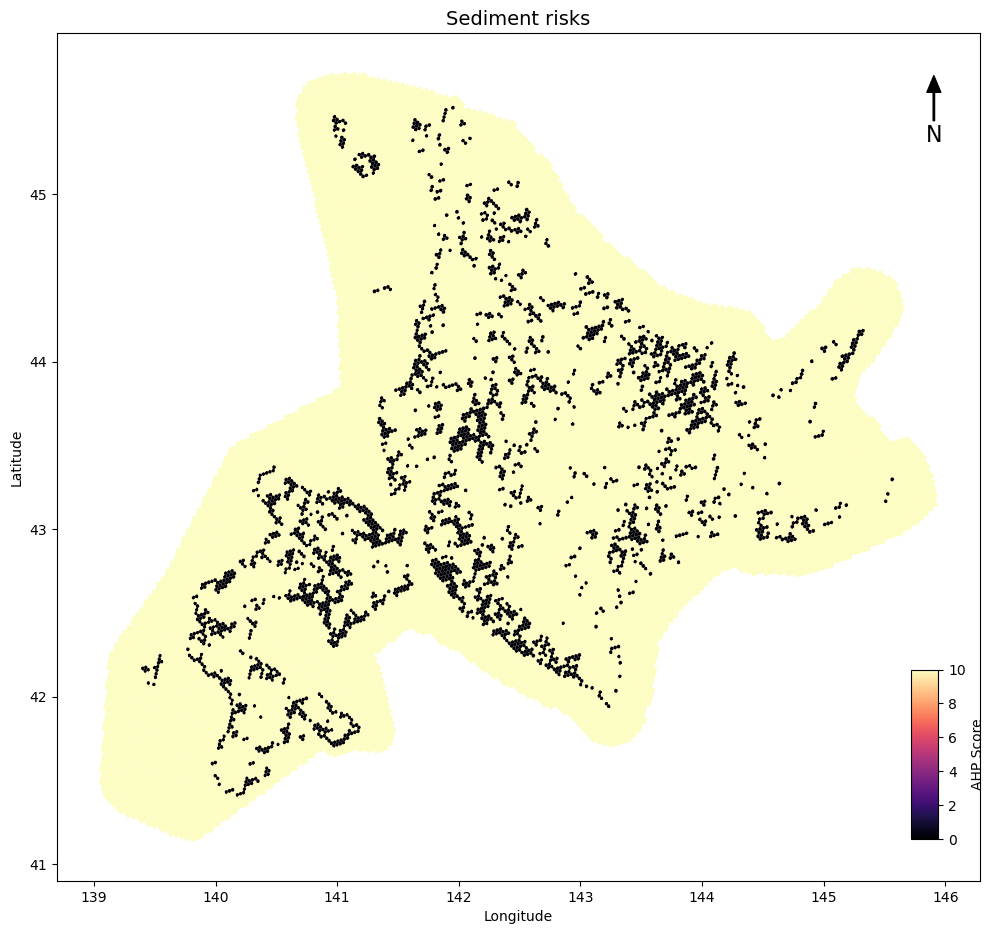

In [22]:
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# 1. Create plot
fig, ax = plt.subplots(figsize=(10, 10))

# 2. Plot main map
main_plot = regions_scored.plot(
    column='ahp_score',
    cmap='magma',
    legend=False,  # We'll add a custom one
    ax=ax,
    edgecolor='none'
)

# 3. Add colorbar INSIDE the plot area
sm = plt.cm.ScalarMappable(cmap='magma', norm=plt.Normalize(vmin=regions_scored['ahp_score'].min(), vmax=regions_scored['ahp_score'].max()))
sm._A = []

cax = inset_axes(ax, width="3%", height="20%", loc='lower right', borderpad=3)  # Adjust size/position here
cbar = fig.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label("AHP Score")

# 4. Coordinate grid and title
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Sediment risks", fontsize=14)

# Add north arrow but arrow shorter
ax.annotate('N',
            xy=(0.95, 0.95), xytext=(0.95, 0.88),
            xycoords='axes fraction',
            ha='center', va='center',
            fontsize=16,
            arrowprops=dict(facecolor='black', width=1, headwidth=10)) 

plt.tight_layout()
plt.show()
